# 📊 Análisis Discriminante Lineal (LDA) y Cuadrático (QDA)
## Reclasificación de Buenos Clientes — Compartamos Financiera

**Curso:** Estadística Aplicada  
**Docente:** Dr. Edgar Eloy Carpio Vargas — FINESI  
**Objetivo:** Aplicar LDA y QDA para reclasificar clientes buenos según sus características financieras y crediticias.

---
### Marco Teórico

El **Análisis Discriminante Lineal (LDA)** es un método de aprendizaje supervisado que busca una combinación lineal de variables independientes (cuantitativas) que maximice la separación entre grupos previamente definidos. En este caso, la variable dependiente es la **categoría del cliente** (A, A+, B) y se busca reclasificarlos correctamente usando variables financieras.

El proceso de **reclasificación** (uso *reclasificador*) permite recomponer la partición existente de grupos para validar o mejorar la clasificación original.

**Supuestos del LDA:**
1. Normalidad multivariante en cada grupo
2. Homogeneidad de matrices de covarianza (Box's M test) → si se viola, se usa **QDA**
3. Ausencia de multicolinealidad severa

**Función discriminante de Fisher:**
$$D = u_1 X_1 + u_2 X_2 + \cdots + u_k X_k$$

## 1. Instalación e Importación de Librerías

In [1]:
# Instalación de librerías necesarias
!pip install -q openpyxl pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Tests estadísticos
from scipy import stats
from scipy.stats import shapiro, bartlett, levene
import pingouin as pg

# Configuración visual
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
COLORS = {'A': '#2196F3', 'A+': '#4CAF50', 'B': '#FF5722'}

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2. Carga y Preparación de Datos

In [3]:
# ── OPCIÓN A: Carga desde Google Drive (recomendado para Colab) ──
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_excel('/content/drive/MyDrive/databuenosclientes.xlsx')

# ── OPCIÓN B: Carga directa desde tu PC ──
from google.colab import files
uploaded = files.upload()   # Selecciona 'databuenosclientes.xlsx'
df_raw = pd.read_excel(list(uploaded.keys())[0])

print(f'✅ Dataset cargado: {df_raw.shape[0]} clientes, {df_raw.shape[1]} variables')
df_raw.head()

Saving databuenosclientes.xlsx to databuenosclientes.xlsx
✅ Dataset cargado: 114 clientes, 25 variables


,codigo oficina,codigo cliente,cliente,monto aprobado de cash,codigo analista,ultima garantia,ultima evaluzacion economica,mora promedio del cliente (dias),atraso maximo del cliente (dias),atraso maximo del cliente ultimos 3 meses (dias),...,numero de empresas en la SBS,deuda directa en la SBS,numero de empresas en la SBS del conyugue,deuda directa en la SBS del conyugue,actividad,Ingresos,egresos,resultado neto,categoria analista,sugerido
0,34,340154400,A,1500,9163,...,2017-10-06,0.44,4,0,...,1.0,344.94,NaN,NaN,Otras actividades,2160,1098,1062,SENIOR,1500.0
1,34,340181221,A,1500,9163,GARANTIA PERSONAL ...,2017-04-06,0.00,0,0,...,1.0,3892.17,NaN,NaN,Comercio x Mayor,4890,3437,1453,SENIOR,1500.0
2,34,340008374,A+,12000,9163,...,2017-07-04,1.35,8,5,...,1.0,904.15,NaN,NaN,Otras actividades,22600,19190,3410,SENIOR,12000.0
3,34,340088509,A,1000,9163,...,2017-02-14,0.67,7,7,...,2.0,21802.17,NaN,NaN,Otras actividades,14040,10528,3512,SENIOR,1000.0
4,34,340085851,A,9000,9163,...,2016-12-05,2.77,19,2,...,3.0,4216.80,NaN,NaN,Otras actividades,3272,530,2742,SENIOR,9000.0


In [4]:
# ── Información general ──
print('=' * 60)
print('ESTRUCTURA DEL DATASET')
print('=' * 60)
df_raw.info()

ESTRUCTURA DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 25 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   codigo oficina                                    114 non-null    int64         
 1   codigo cliente                                    114 non-null    int64         
 2   cliente                                           114 non-null    object        
 3   monto aprobado de cash                            114 non-null    int64         
 4   codigo analista                                   114 non-null    object        
 5   ultima garantia                                   114 non-null    object        
 6   ultima evaluzacion economica                      114 non-null    datetime64[ns]
 7   mora promedio del cliente (dias)                  114 non-null    float64       
 8   atraso 

In [5]:
# ── Distribución de la variable objetivo ──
print('Distribución de categorías de cliente (variable dependiente):')
print(df_raw['cliente'].value_counts())
print()
print('Distribución de categoría analista:')
print(df_raw['categoria analista'].value_counts())

Distribución de categorías de cliente (variable dependiente):
cliente
A     61
A+    28
B     25
Name: count, dtype: int64

Distribución de categoría analista:
categoria analista
JUNIOR 1             39
JUNIOR               28
PRINCIPIANTE         20
SENIOR               10
EXPERTO              10
MASTER                6
JUNIOR1 C/CARTERA     1
Name: count, dtype: int64


In [6]:
# ── Selección de variables y limpieza ──
# Variable dependiente: 'cliente' (A, A+, B)
# Variables independientes: numéricas relevantes para el perfil crediticio

VARS_INDEP = [
    'mora promedio del cliente (dias)',
    'atraso maximo del cliente (dias)',
    'atraso maximo del cliente ultimos 3 meses (dias)',
    'numero de creditos vigentes',
    'maximo capital desembolsado vigente',
    'deuda total en compartamos',
    'numero de empresas en la SBS',
    'deuda directa en la SBS',
    'Ingresos',
    'egresos',
    'resultado neto',
    'monto aprobado de cash'
]

VAR_DEP = 'cliente'

# Crear copia de trabajo
df = df_raw[[VAR_DEP] + VARS_INDEP].copy()

# Imputar nulos numéricos con la mediana de cada grupo
for col in VARS_INDEP:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(f'  → Columna "{col}": {df[col].isnull().sum()} nulos imputados con mediana ({mediana:.2f})')

# Eliminar filas con variable dependiente nula
df.dropna(subset=[VAR_DEP], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\n✅ Dataset limpio: {df.shape[0]} filas × {df.shape[1]} columnas')
df.describe().round(2)

  → Columna "numero de empresas en la SBS": 0 nulos imputados con mediana (2.00)
  → Columna "deuda directa en la SBS": 0 nulos imputados con mediana (2480.13)

✅ Dataset limpio: 114 filas × 13 columnas


,mora promedio del cliente (dias),atraso maximo del cliente (dias),atraso maximo del cliente ultimos 3 meses (dias),numero de creditos vigentes,maximo capital desembolsado vigente,deuda total en compartamos,numero de empresas en la SBS,deuda directa en la SBS,Ingresos,egresos,resultado neto,monto aprobado de cash
count,114.00,114.00,114.00,114.00,114.00,114.00,114.00,114.00,114.00,114.00,114.00,114.00
mean,1.19,7.66,2.73,1.07,5017.30,3476.09,1.67,5555.85,6182.13,3882.27,2339.92,4526.32
std,1.27,7.62,2.92,0.59,6315.87,4806.07,0.70,6680.98,4419.26,3752.40,1296.05,4034.06
min,0.00,0.00,0.00,0.00,0.00,0.00,1.00,97.74,0.00,0.00,737.00,1000.00
25%,0.35,2.25,0.25,1.00,1000.00,713.87,1.00,1255.55,3170.00,1135.50,1453.25,1500.00
50%,0.83,6.00,2.00,1.00,2000.00,1555.97,2.00,2480.13,4840.50,2812.50,1930.00,3000.00
75%,1.64,10.75,4.00,1.00,5044.25,3643.43,2.00,7646.26,8375.00,5031.00,2862.00,6000.00
max,8.50,54.00,14.00,2.00,30000.00,20899.22,3.00,34098.07,22991.00,19190.00,7815.00,20000.00


## 3. Exploración Gráfica de los Datos

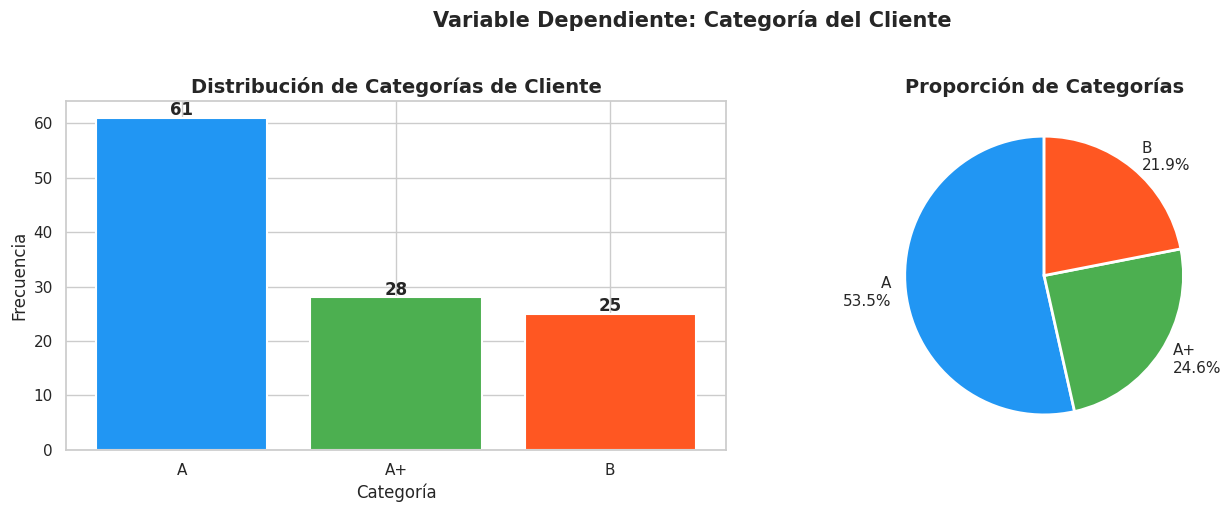


📌 Probabilidades a priori (π̂k):
   π̂(A) = 0.5351 (53.5%)
   π̂(A+) = 0.2456 (24.6%)
   π̂(B) = 0.2193 (21.9%)


In [7]:
# ── Distribución de la variable dependiente ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteos = df[VAR_DEP].value_counts()
colores = [COLORS.get(c, '#999') for c in conteos.index]

axes[0].bar(conteos.index, conteos.values, color=colores, edgecolor='white', linewidth=1.5)
for i, (cat, val) in enumerate(zip(conteos.index, conteos.values)):
    axes[0].text(i, val + 0.5, str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Categorías de Cliente', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Frecuencia')

porcentajes = conteos / conteos.sum() * 100
axes[1].pie(porcentajes, labels=[f'{c}\n{p:.1f}%' for c, p in zip(porcentajes.index, porcentajes)],
            colors=colores, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporción de Categorías', fontsize=14, fontweight='bold')

plt.suptitle('Variable Dependiente: Categoría del Cliente', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\n📌 Probabilidades a priori (π̂k):')
for cat, prop in (df[VAR_DEP].value_counts(normalize=True)).items():
    print(f'   π̂({cat}) = {prop:.4f} ({prop*100:.1f}%)')

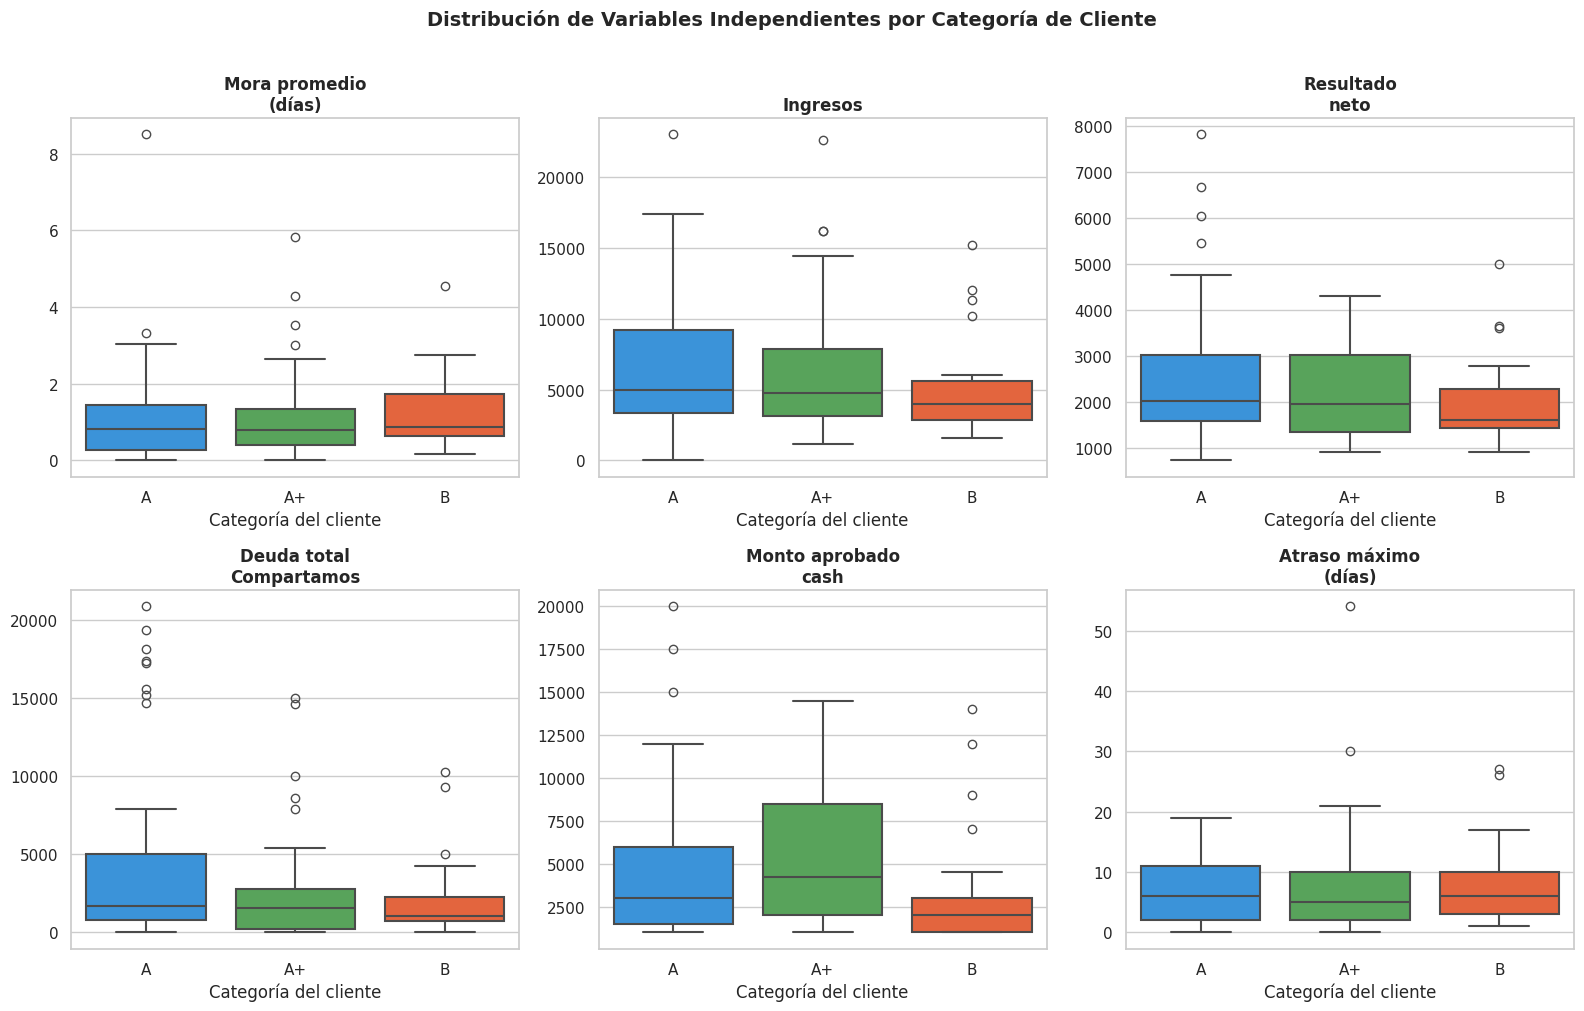

In [8]:
# ── Boxplots de variables independientes por categoría ──
VARS_PLOT = ['mora promedio del cliente (dias)', 'Ingresos', 'resultado neto',
             'deuda total en compartamos', 'monto aprobado de cash',
             'atraso maximo del cliente (dias)']

LABELS_CORTOS = ['Mora promedio\n(días)', 'Ingresos', 'Resultado\nneto',
                 'Deuda total\nCompartamos', 'Monto aprobado\ncash', 'Atraso máximo\n(días)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
orden = ['A', 'A+', 'B']
paleta = [COLORS[c] for c in orden]

for i, (var, label) in enumerate(zip(VARS_PLOT, LABELS_CORTOS)):
    sns.boxplot(data=df, x=VAR_DEP, y=var, order=orden,
                palette=paleta, ax=axes[i], linewidth=1.5)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Categoría del cliente')
    axes[i].set_ylabel('')

plt.suptitle('Distribución de Variables Independientes por Categoría de Cliente',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

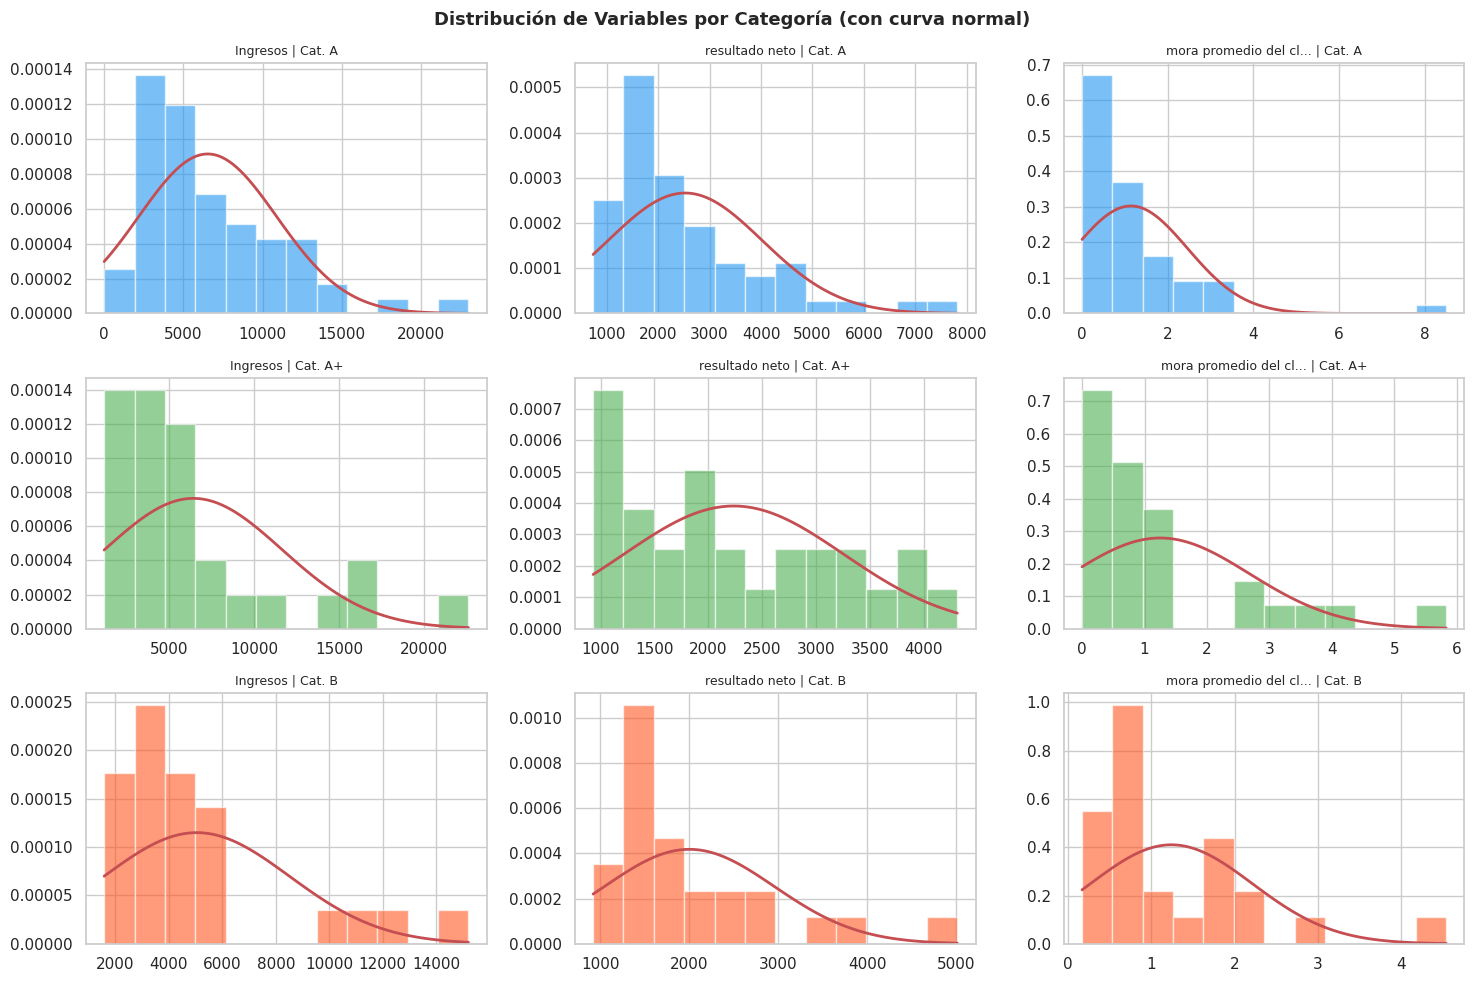

In [9]:
# ── Histogramas con curva normal superpuesta por categoría ──
VARS_H = ['Ingresos', 'resultado neto', 'mora promedio del cliente (dias)']
fig, axes = plt.subplots(len(orden), len(VARS_H), figsize=(15, 10))

for j, var in enumerate(VARS_H):
    for i, cat in enumerate(orden):
        datos = df[df[VAR_DEP] == cat][var]
        ax = axes[i][j]
        ax.hist(datos, density=True, bins=12, color=paleta[i], alpha=0.6, edgecolor='white')
        # Curva normal
        xmin, xmax = datos.min(), datos.max()
        x = np.linspace(xmin, xmax, 100)
        ax.plot(x, stats.norm.pdf(x, datos.mean(), datos.std()), 'r-', lw=2)
        ax.set_title(f'{var[:20]}... | Cat. {cat}' if len(var) > 20 else f'{var} | Cat. {cat}',
                     fontsize=9)
        ax.set_xlabel('')

plt.suptitle('Distribución de Variables por Categoría (con curva normal)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

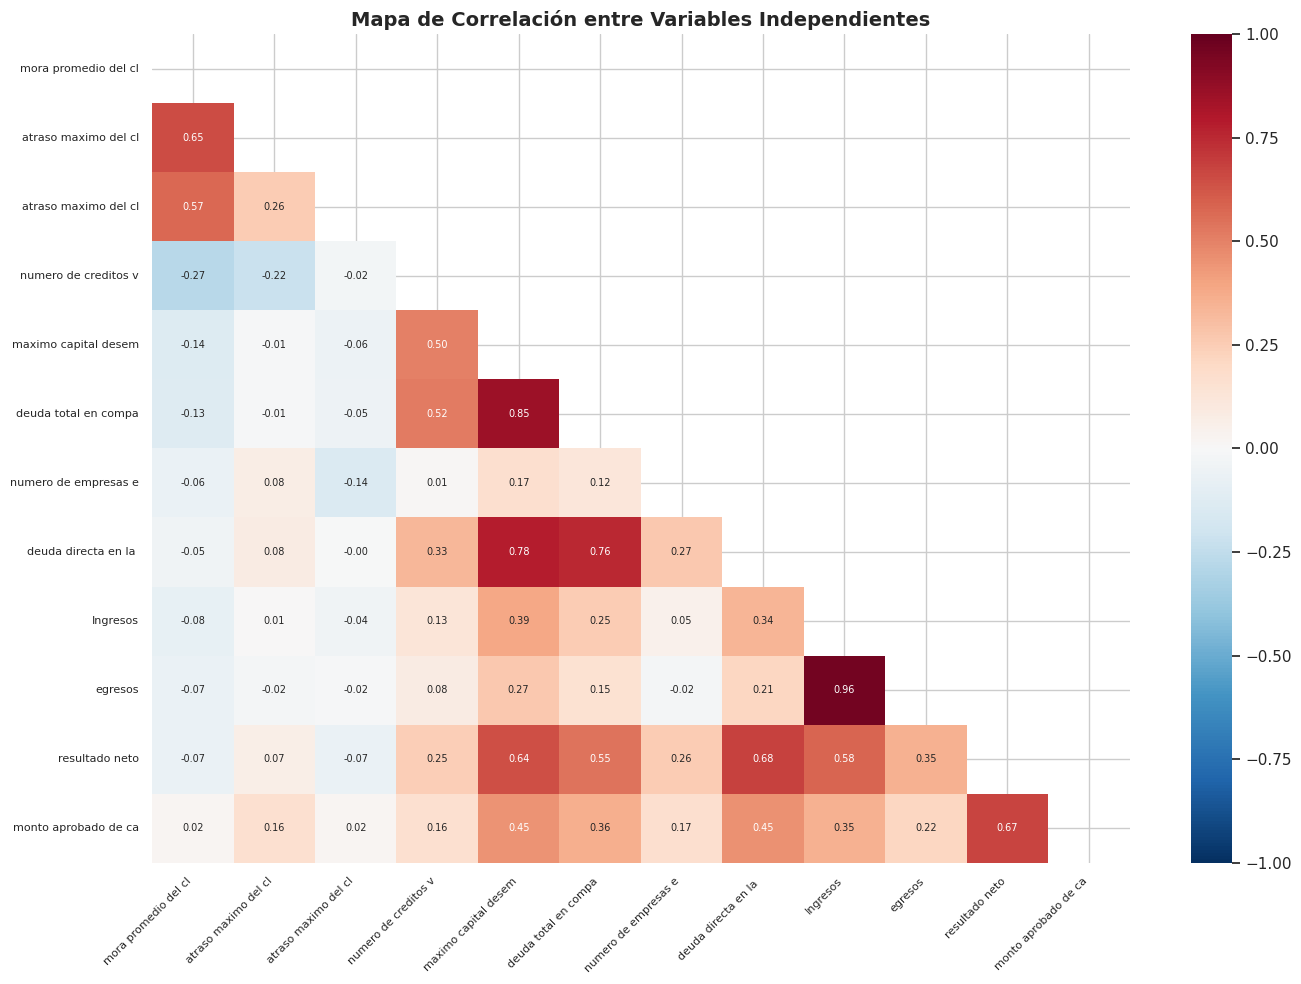

📌 Nota: Correlaciones altas (|r| > 0.7) pueden indicar multicolinealidad.


In [10]:
# ── Mapa de calor de correlaciones ──
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[VARS_INDEP].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7},
            xticklabels=[v[:20] for v in VARS_INDEP],
            yticklabels=[v[:20] for v in VARS_INDEP])
ax.set_title('Mapa de Correlación entre Variables Independientes', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()
print('📌 Nota: Correlaciones altas (|r| > 0.7) pueden indicar multicolinealidad.')

## 4. Verificación de Supuestos

### 4.1 Supuesto 1: Normalidad Univariante (Test Shapiro-Wilk)

In [11]:
print('=' * 70)
print('PRUEBA DE NORMALIDAD SHAPIRO-WILK POR VARIABLE Y CATEGORÍA')
print('H₀: La variable sigue distribución normal')
print('Se rechaza H₀ si p-valor < 0.05')
print('=' * 70)

resultados_sw = []
for cat in orden:
    for var in VARS_INDEP:
        datos = df[df[VAR_DEP] == cat][var].dropna()
        if len(datos) >= 3:
            stat, p = shapiro(datos)
            normal = '✅ SÍ' if p >= 0.05 else '❌ NO'
            resultados_sw.append({'Categoría': cat, 'Variable': var[:30],
                                   'W': round(stat, 4), 'p-valor': round(p, 4), 'Normal': normal})

df_sw = pd.DataFrame(resultados_sw)
print(df_sw.to_string(index=False))

n_no_normal = (df_sw['Normal'] == '❌ NO').sum()
print(f'\n📊 Resumen: {n_no_normal} de {len(df_sw)} combinaciones NO cumplen normalidad')
print('📌 Nota: El LDA es robusto ante ligeras violaciones de normalidad univariante.')

PRUEBA DE NORMALIDAD SHAPIRO-WILK POR VARIABLE Y CATEGORÍA
H₀: La variable sigue distribución normal
Se rechaza H₀ si p-valor < 0.05
Categoría                       Variable      W  p-valor Normal
        A mora promedio del cliente (dia 0.7149   0.0000   ❌ NO
        A atraso maximo del cliente (dia 0.9143   0.0004   ❌ NO
        A atraso maximo del cliente ulti 0.8465   0.0000   ❌ NO
        A    numero de creditos vigentes 0.7323   0.0000   ❌ NO
        A maximo capital desembolsado vi 0.7580   0.0000   ❌ NO
        A     deuda total en compartamos 0.7056   0.0000   ❌ NO
        A   numero de empresas en la SBS 0.7837   0.0000   ❌ NO
        A        deuda directa en la SBS 0.7809   0.0000   ❌ NO
        A                       Ingresos 0.8980   0.0001   ❌ NO
        A                        egresos 0.8767   0.0000   ❌ NO
        A                 resultado neto 0.8500   0.0000   ❌ NO
        A         monto aprobado de cash 0.7845   0.0000   ❌ NO
       A+ mora promedio del cliente

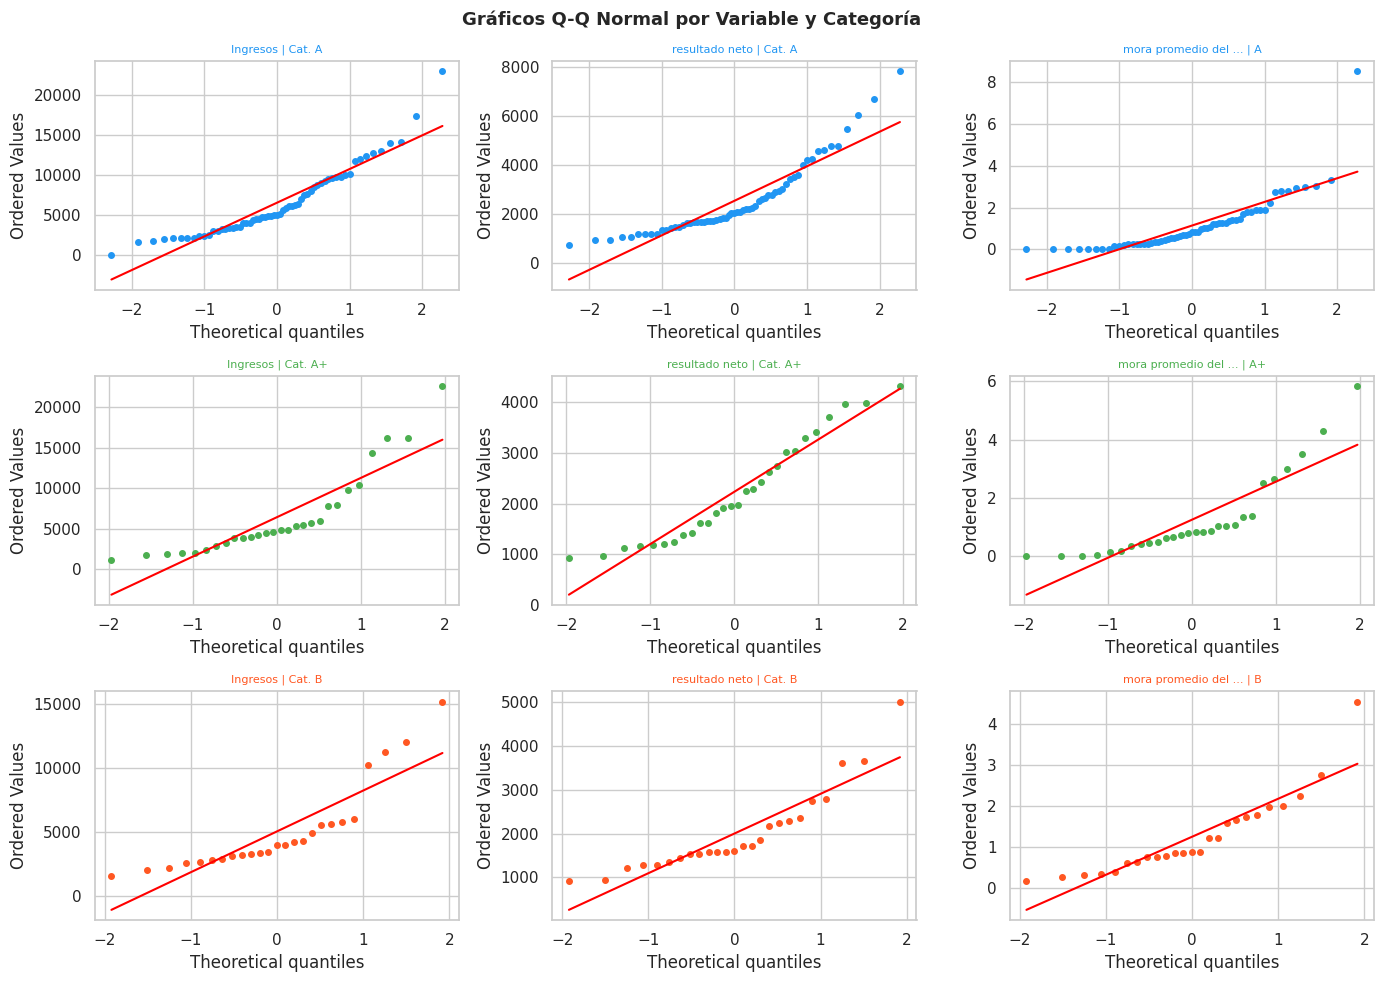

In [12]:
# ── Gráficos Q-Q por variable y categoría ──
VARS_QQ = ['Ingresos', 'resultado neto', 'mora promedio del cliente (dias)']
fig, axes = plt.subplots(len(orden), len(VARS_QQ), figsize=(14, 10))

for j, var in enumerate(VARS_QQ):
    for i, cat in enumerate(orden):
        datos = df[df[VAR_DEP] == cat][var].dropna()
        ax = axes[i][j]
        stats.probplot(datos, dist='norm', plot=ax)
        ax.set_title(f'{var[:18]}... | {cat}' if len(var) > 18 else f'{var} | Cat. {cat}',
                     fontsize=8, color=paleta[i])
        ax.get_lines()[0].set(color=paleta[i], markersize=4)
        ax.get_lines()[1].set(color='red', lw=1.5)

plt.suptitle('Gráficos Q-Q Normal por Variable y Categoría', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Supuesto 2: Homogeneidad de Matrices de Covarianza (Box's M aproximado)

In [13]:
# ── Levene test por variable (proxy multivariante) ──
print('=' * 65)
print('PRUEBA DE HOMOGENEIDAD DE VARIANZAS (Levene por variable)')
print('H₀: Las varianzas son iguales en todos los grupos')
print('Se rechaza H₀ si p-valor < 0.05  → podría preferirse QDA')
print('=' * 65)

grupos = {cat: df[df[VAR_DEP] == cat] for cat in orden}
levene_results = []
for var in VARS_INDEP:
    muestras = [grupos[cat][var].dropna() for cat in orden]
    stat, p = levene(*muestras)
    homogeneo = '✅ SÍ' if p >= 0.05 else '❌ NO'
    levene_results.append({'Variable': var[:35], 'Levene W': round(stat, 4),
                            'p-valor': round(p, 4), 'Homogéneo': homogeneo})

df_lev = pd.DataFrame(levene_results)
print(df_lev.to_string(index=False))

n_no_hom = (df_lev['Homogéneo'] == '❌ NO').sum()
print(f'\n📊 Resumen: {n_no_hom} de {len(df_lev)} variables NO son homogéneas')
if n_no_hom > len(df_lev) // 2:
    print('⚠️  Mayoría de variables violan homogeneidad → QDA puede ser más apropiado')
else:
    print('✅ Mayoría de variables cumplen homogeneidad → LDA es apropiado')

PRUEBA DE HOMOGENEIDAD DE VARIANZAS (Levene por variable)
H₀: Las varianzas son iguales en todos los grupos
Se rechaza H₀ si p-valor < 0.05  → podría preferirse QDA
                           Variable  Levene W  p-valor Homogéneo
   mora promedio del cliente (dias)    0.3220   0.7254      ✅ SÍ
   atraso maximo del cliente (dias)    1.2102   0.3020      ✅ SÍ
atraso maximo del cliente ultimos 3    0.5427   0.5827      ✅ SÍ
        numero de creditos vigentes    0.2010   0.8182      ✅ SÍ
maximo capital desembolsado vigente    1.8364   0.1642      ✅ SÍ
         deuda total en compartamos    1.6476   0.1972      ✅ SÍ
       numero de empresas en la SBS    3.2048   0.0443      ❌ NO
            deuda directa en la SBS    3.6269   0.0298      ❌ NO
                           Ingresos    0.9597   0.3862      ✅ SÍ
                            egresos    0.7224   0.4878      ✅ SÍ
                     resultado neto    1.6394   0.1988      ✅ SÍ
             monto aprobado de cash    0.9473   0.3909 

MATRICES DE COVARIANZA POR GRUPO (variables principales)


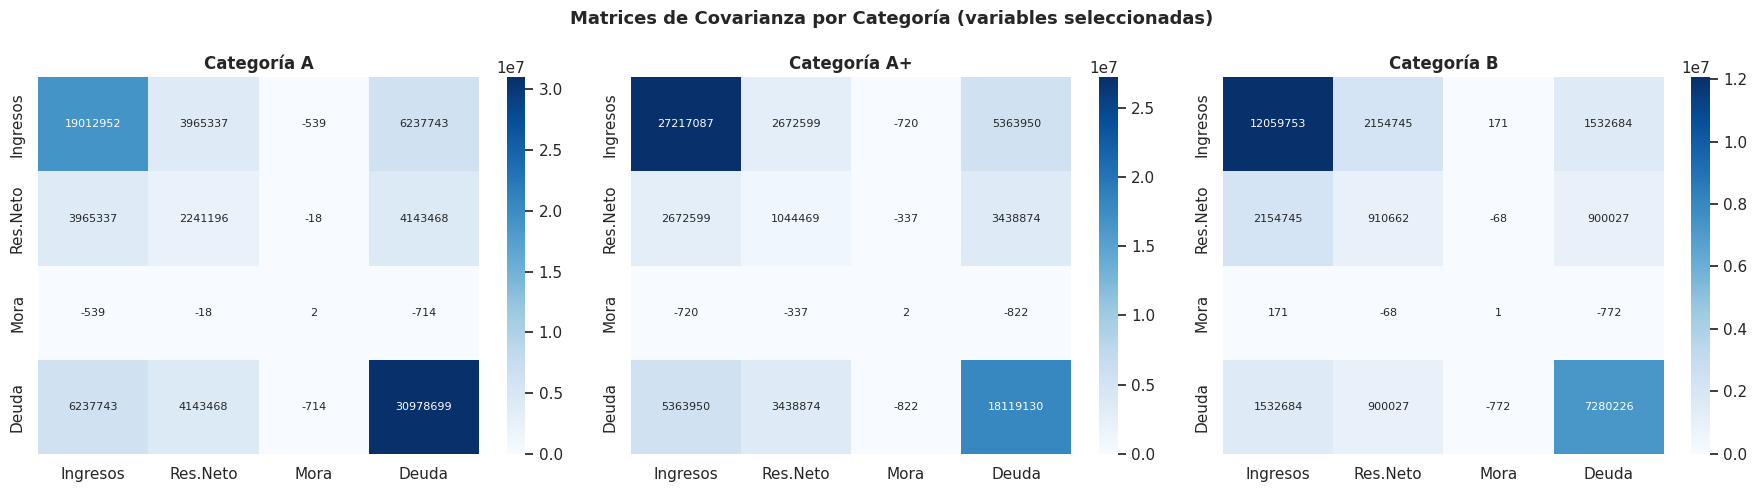

📌 Si las matrices son muy diferentes entre grupos → preferir QDA


In [14]:
# ── Matrices de covarianza por grupo ──
print('MATRICES DE COVARIANZA POR GRUPO (variables principales)')
VARS_COV = ['Ingresos', 'resultado neto', 'mora promedio del cliente (dias)', 'deuda total en compartamos']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cat in enumerate(orden):
    cov = df[df[VAR_DEP] == cat][VARS_COV].cov()
    sns.heatmap(cov, annot=True, fmt='.0f', cmap='Blues', ax=axes[i],
                xticklabels=['Ingresos','Res.Neto','Mora','Deuda'],
                yticklabels=['Ingresos','Res.Neto','Mora','Deuda'],
                annot_kws={'size': 8})
    axes[i].set_title(f'Categoría {cat}', fontsize=12, fontweight='bold')

plt.suptitle('Matrices de Covarianza por Categoría (variables seleccionadas)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Si las matrices son muy diferentes entre grupos → preferir QDA')

### 4.3 Supuesto 3: Multicolinealidad

In [15]:
# ── Factor de Inflación de Varianza (VIF) ──
from numpy.linalg import det

X_check = df[VARS_INDEP].values
corr_matrix = np.corrcoef(X_check.T)

print('=' * 55)
print('ANÁLISIS DE MULTICOLINEALIDAD (Correlaciones > 0.7)')
print('=' * 55)
corr_df = pd.DataFrame(corr_matrix, index=VARS_INDEP, columns=VARS_INDEP)
altas = []
for i in range(len(VARS_INDEP)):
    for j in range(i+1, len(VARS_INDEP)):
        r = corr_matrix[i, j]
        if abs(r) > 0.7:
            altas.append({'V1': VARS_INDEP[i][:25], 'V2': VARS_INDEP[j][:25], 'r': round(r, 4)})

if altas:
    print('Pares con correlación |r| > 0.7:')
    print(pd.DataFrame(altas).to_string(index=False))
    print('⚠️  Existe multicolinealidad. Considerar selección de variables.')
else:
    print('✅ No se detecta multicolinealidad severa (|r| > 0.7)')

print(f'\nDeterminante de la matriz de correlación: {det(corr_matrix):.6f}')
print('(Valores cercanos a 0 indican alta multicolinealidad)')

ANÁLISIS DE MULTICOLINEALIDAD (Correlaciones > 0.7)
Pares con correlación |r| > 0.7:
                       V1                        V2      r
maximo capital desembolsa deuda total en compartamo 0.8531
maximo capital desembolsa   deuda directa en la SBS 0.7839
deuda total en compartamo   deuda directa en la SBS 0.7551
                 Ingresos                   egresos 0.9627
⚠️  Existe multicolinealidad. Considerar selección de variables.

Determinante de la matriz de correlación: 0.000025
(Valores cercanos a 0 indican alta multicolinealidad)


## 5. Preparación Final para el Modelo

In [16]:
# ── Codificación de variable dependiente y escalado ──
X = df[VARS_INDEP].values
y = df[VAR_DEP].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
clases = le.classes_

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Clases codificadas:', dict(zip(clases, le.transform(clases))))
print(f'Tamaño X: {X.shape}')
print(f'Distribución de y: {dict(zip(*np.unique(y, return_counts=True)))}')

# Probabilidades a priori
print('\n📊 Probabilidades a priori (π̂k):')
for cat in clases:
    pi = (y == cat).mean()
    print(f'   π̂({cat}) = {pi:.4f}')

Clases codificadas: {'A': np.int64(0), 'A+': np.int64(1), 'B': np.int64(2)}
Tamaño X: (114, 12)
Distribución de y: {'A': np.int64(61), 'A+': np.int64(28), 'B': np.int64(25)}

📊 Probabilidades a priori (π̂k):
   π̂(A) = 0.5351
   π̂(A+) = 0.2456
   π̂(B) = 0.2193


## 6. Ajuste del Modelo LDA (Análisis Discriminante Lineal)

In [17]:
# ── Entrenamiento del modelo LDA (reclasificación: misma data) ──
lda = LinearDiscriminantAnalysis(solver='svd', store_covariance=True)
lda.fit(X_scaled, y_enc)

print('=' * 60)
print('MODELO LDA — PARÁMETROS ESTIMADOS')
print('=' * 60)

print('\n📌 Probabilidades a priori:')
for cls, pi in zip(clases, lda.priors_):
    print(f'   π̂({cls}) = {pi:.4f}')

print('\n📌 Medias de grupo (μ̂k) — espacio escalado:')
df_medias = pd.DataFrame(lda.means_, index=clases,
                          columns=[v[:20] for v in VARS_INDEP])
print(df_medias.round(3).to_string())

print(f'\n📌 Número de funciones discriminantes: {lda.scalings_.shape[1]}')
print(f'   (máx = min(G-1, p) = min({len(clases)-1}, {len(VARS_INDEP)}) = {min(len(clases)-1, len(VARS_INDEP))})')

MODELO LDA — PARÁMETROS ESTIMADOS

📌 Probabilidades a priori:
   π̂(A) = 0.5351
   π̂(A+) = 0.2456
   π̂(B) = 0.2193

📌 Medias de grupo (μ̂k) — espacio escalado:
    mora promedio del cl  atraso maximo del cl  atraso maximo del cl  numero de creditos v  maximo capital desem  deuda total en compa  numero de empresas e  deuda directa en la   Ingresos  egresos  resultado neto  monto aprobado de ca
A                 -0.039                -0.115                 0.060                 0.104                 0.174                 0.156                 0.196                 0.236     0.080    0.054           0.144                 0.004
A+                 0.048                 0.172                -0.226                 0.002                -0.149                -0.079                -0.342                -0.329     0.057    0.084          -0.080                 0.296
B                  0.042                 0.087                 0.107                -0.255                -0.257                -0

In [18]:
# ── Coeficientes discriminantes ──
print('=' * 60)
print('COEFICIENTES DE LAS FUNCIONES DISCRIMINANTES (escalings)')
print('=' * 60)

n_func = lda.scalings_.shape[1]
cols_func = [f'LD{i+1}' for i in range(n_func)]

df_coef = pd.DataFrame(lda.scalings_, index=VARS_INDEP, columns=cols_func)
print(df_coef.round(4).to_string())

# Varianza explicada
print('\n📊 Proporción de varianza explicada por cada función:')
exp_var = lda.explained_variance_ratio_
for i, (func, var) in enumerate(zip(cols_func, exp_var)):
    print(f'   {func}: {var:.4f} ({var*100:.2f}%)')

# Función discriminante escrita
print('\n📐 Función Discriminante LD1:')
terminos = [f'{coef:+.4f}×{var[:15]}' for coef, var in zip(lda.scalings_[:, 0], VARS_INDEP)]
print('D1 = ' + ' '.join(terminos[:4]))
print('     ' + ' '.join(terminos[4:8]))
if len(terminos) > 8:
    print('     ' + ' '.join(terminos[8:]))

COEFICIENTES DE LAS FUNCIONES DISCRIMINANTES (escalings)
                                                     LD1     LD2
mora promedio del cliente (dias)                  0.1547 -0.5735
atraso maximo del cliente (dias)                  0.3117  0.5904
atraso maximo del cliente ultimos 3 meses (dias) -0.5521  0.2647
numero de creditos vigentes                       0.1382 -0.3394
maximo capital desembolsado vigente              -0.3171  0.3523
deuda total en compartamos                        0.5372 -0.5821
numero de empresas en la SBS                     -0.4510 -0.3074
deuda directa en la SBS                          -0.7820 -0.1053
Ingresos                                          0.8704 -0.7112
egresos                                          -0.5886  0.2328
resultado neto                                   -0.5634  0.3545
monto aprobado de cash                            0.8725 -0.5330

📊 Proporción de varianza explicada por cada función:
   LD1: 0.7932 (79.32%)
   LD2: 0.2068 (20.6

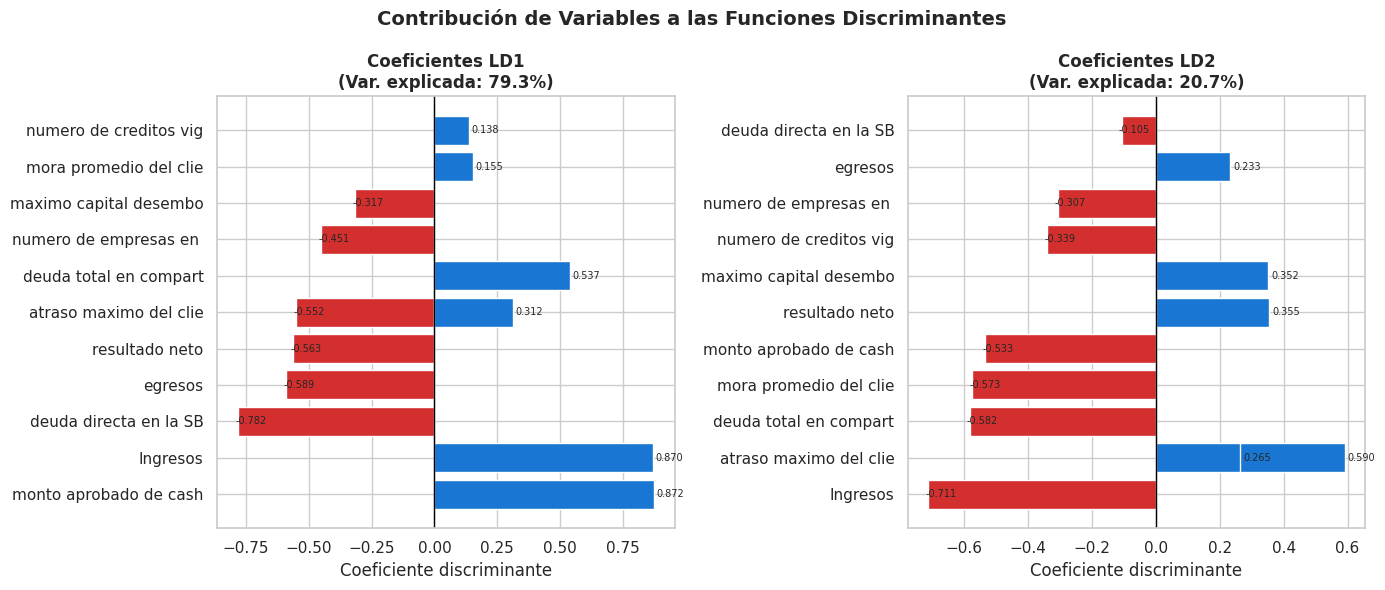

In [19]:
# ── Gráfico de coeficientes discriminantes ──
fig, axes = plt.subplots(1, n_func, figsize=(7*n_func, 6))
if n_func == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    coefs = lda.scalings_[:, i]
    idx_orden = np.argsort(np.abs(coefs))[::-1]
    vars_ord = [VARS_INDEP[j][:22] for j in idx_orden]
    coefs_ord = coefs[idx_orden]
    colores_bar = ['#1976D2' if c > 0 else '#D32F2F' for c in coefs_ord]
    bars = ax.barh(vars_ord, coefs_ord, color=colores_bar, edgecolor='white')
    ax.axvline(0, color='black', lw=1)
    ax.set_title(f'Coeficientes LD{i+1}\n(Var. explicada: {exp_var[i]*100:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Coeficiente discriminante')
    for bar, coef in zip(bars, coefs_ord):
        ax.text(coef + 0.01*np.sign(coef), bar.get_y() + bar.get_height()/2,
                f'{coef:.3f}', va='center', fontsize=7)

plt.suptitle('Contribución de Variables a las Funciones Discriminantes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Reclasificación: Predicciones y Probabilidades Posteriores

In [20]:
# ── Predicción (reclasificación sobre la misma data) ──
y_pred_enc = lda.predict(X_scaled)
y_pred = le.inverse_transform(y_pred_enc)
proba_posterior = lda.predict_proba(X_scaled)
puntuaciones_ld = lda.transform(X_scaled)

# Construir tabla de resultados
df_resultados = df.copy()
df_resultados['Clase_Real'] = y
df_resultados['Clase_Predicha_LDA'] = y_pred
df_resultados['Correcta'] = df_resultados['Clase_Real'] == df_resultados['Clase_Predicha_LDA']

for i, cls in enumerate(clases):
    df_resultados[f'P_posterior_{cls}'] = proba_posterior[:, i].round(4)

for i in range(n_func):
    df_resultados[f'LD{i+1}'] = puntuaciones_ld[:, i].round(4)

print('TABLA DE RECLASIFICACIÓN LDA (primeras 20 filas):')
cols_mostrar = ['Clase_Real', 'Clase_Predicha_LDA', 'Correcta'] + \
               [f'P_posterior_{c}' for c in clases] + \
               [f'LD{i+1}' for i in range(n_func)]
print(df_resultados[cols_mostrar].head(20).to_string())

print(f'\n✅ Predicciones completadas: {len(df_resultados)} clientes reclasificados')

TABLA DE RECLASIFICACIÓN LDA (primeras 20 filas):
   Clase_Real Clase_Predicha_LDA  Correcta  P_posterior_A  P_posterior_A+  P_posterior_B     LD1     LD2
0           A                  A      True         0.3691          0.3489         0.2820  0.7718  0.8272
1           A                  A      True         0.5072          0.2320         0.2608  0.2330  0.3732
2          A+                 A+      True         0.1465          0.8261         0.0274  2.4320 -1.6986
3           A                  A      True         0.8594          0.0031         0.1376 -3.5809 -0.3974
4           A                  A      True         0.5150          0.3092         0.1758  0.5131 -0.3107
5           A                 A+     False         0.2272          0.7420         0.0309  2.0294 -2.0753
6           A                  A      True         0.7332          0.1896         0.0772 -0.0117 -1.9356
7          A+                  A     False         0.4349          0.3759         0.1892  0.7774 -0.0157
8    

## 8. Evaluación del Modelo LDA

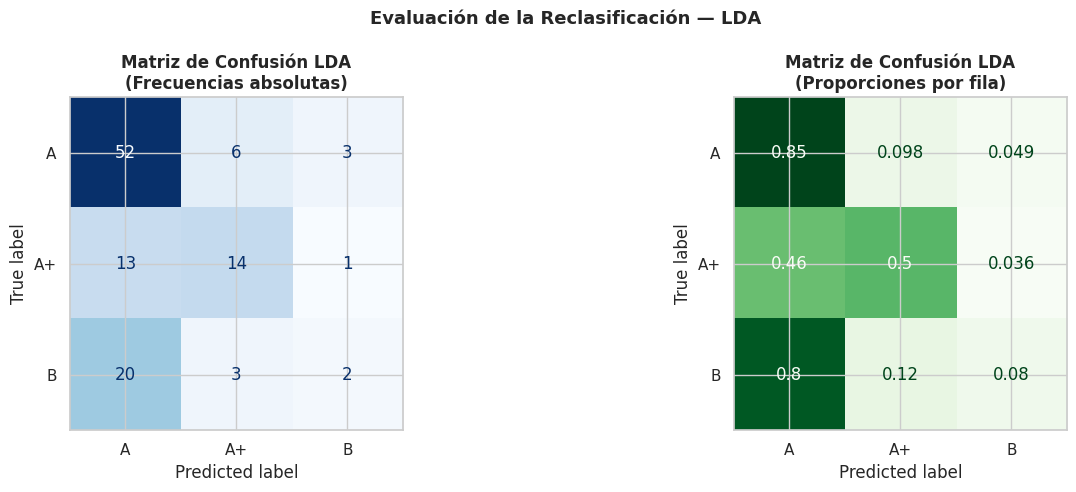

In [21]:
# ── Matriz de confusión ──
cm = confusion_matrix(y, y_pred, labels=clases)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frecuencias absolutas
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión LDA\n(Frecuencias absolutas)', fontweight='bold')

# Proporciones por fila
cm_prop = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_prop.round(3), display_labels=clases)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de Confusión LDA\n(Proporciones por fila)', fontweight='bold')

plt.suptitle('Evaluación de la Reclasificación — LDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── Métricas de clasificación ──
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)
training_error = (1 - accuracy) * 100

print('=' * 65)
print('MÉTRICAS DE EVALUACIÓN — LDA (Training Error)')
print('=' * 65)
print(f'\n✅ Precisión global (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'❌ Error de entrenamiento:      {training_error:.2f}%')

print('\n📊 Reporte de clasificación por categoría:')
print(classification_report(y, y_pred, target_names=clases))

print('\n📊 Tabla de clasificación detallada:')
tabla = pd.crosstab(pd.Series(y, name='Clase Real'),
                    pd.Series(y_pred, name='Clase Predicha'),
                    margins=True, margins_name='Total')
print(tabla)

MÉTRICAS DE EVALUACIÓN — LDA (Training Error)

✅ Precisión global (Accuracy): 0.5965 (59.65%)
❌ Error de entrenamiento:      40.35%

📊 Reporte de clasificación por categoría:
              precision    recall  f1-score   support

           A       0.61      0.85      0.71        61
          A+       0.61      0.50      0.55        28
           B       0.33      0.08      0.13        25

    accuracy                           0.60       114
   macro avg       0.52      0.48      0.46       114
weighted avg       0.55      0.60      0.54       114


📊 Tabla de clasificación detallada:
Clase Predicha   A  A+  B  Total
Clase Real                      
A               52   6  3     61
A+              13  14  1     28
B               20   3  2     25
Total           85  23  6    114


In [23]:
# ── Validación Cruzada (Leave-One-Out y k-fold) ──
print('=' * 60)
print('VALIDACIÓN CRUZADA — LDA')
print('=' * 60)

# k-fold estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearDiscriminantAnalysis(solver='svd'),
                             X_scaled, y_enc, cv=cv, scoring='accuracy')

print(f'\n5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Scores por fold: {cv_scores.round(4)}')

# Leave-One-Out
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
loo_scores = cross_val_score(LinearDiscriminantAnalysis(solver='svd'),
                              X_scaled, y_enc, cv=loo, scoring='accuracy')
print(f'\nLOO CV Accuracy:    {loo_scores.mean():.4f} ({loo_scores.mean()*100:.2f}%)')
print(f'LOO Error rate:     {(1-loo_scores.mean())*100:.2f}%')

print('\n📌 Nota: El training error tiende a ser optimista.')
print('         El LOO CV error es una estimación más realista del test error.')

VALIDACIÓN CRUZADA — LDA

5-Fold CV Accuracy: 0.5348 ± 0.0379
Scores por fold: [0.5217 0.5217 0.6087 0.5217 0.5   ]

LOO CV Accuracy:    0.4649 (46.49%)
LOO Error rate:     53.51%

📌 Nota: El training error tiende a ser optimista.
         El LOO CV error es una estimación más realista del test error.


## 9. Visualización del Espacio Discriminante

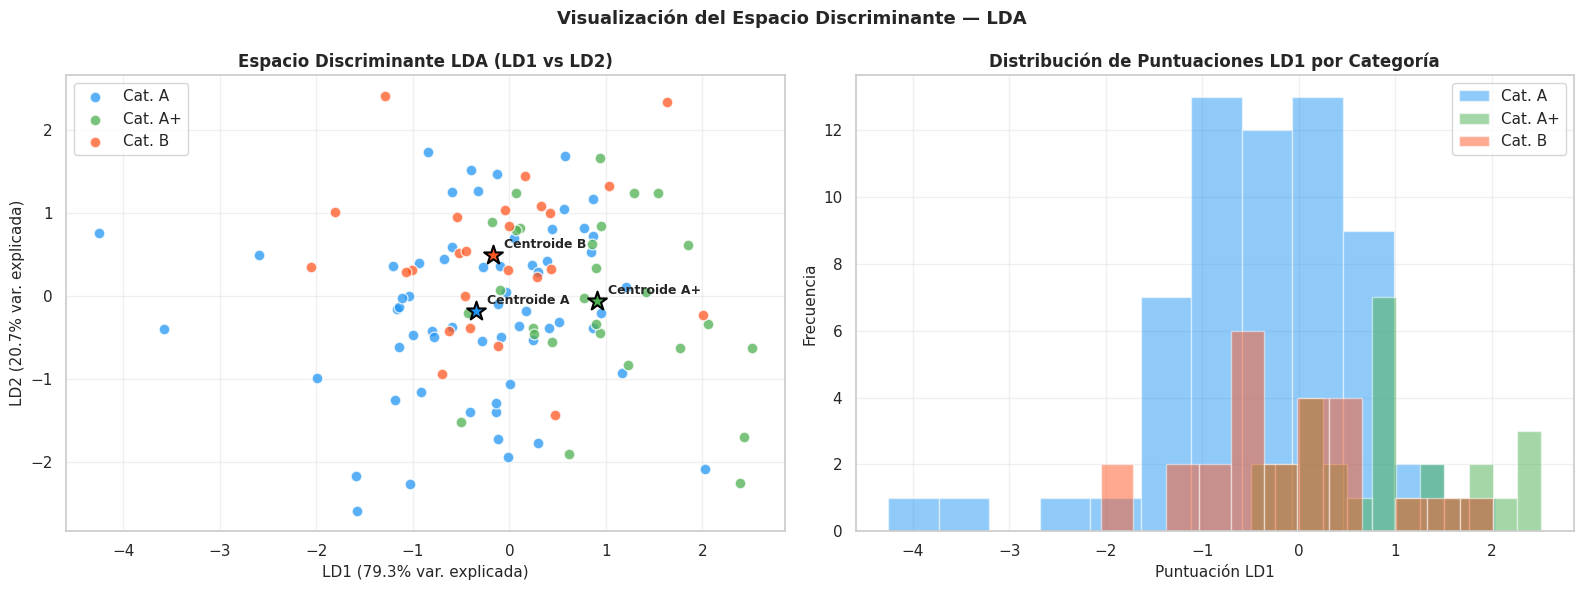

In [24]:
# ── Puntuaciones discriminantes ──
LD_scores = lda.transform(X_scaled)

if n_func >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico LD1 vs LD2
    ax = axes[0]
    for cat in clases:
        mask = y == cat
        ax.scatter(LD_scores[mask, 0], LD_scores[mask, 1],
                   c=COLORS[cat], label=f'Cat. {cat}', s=60, alpha=0.75, edgecolors='white')
        # Centroide
        cx, cy = LD_scores[mask, 0].mean(), LD_scores[mask, 1].mean()
        ax.scatter(cx, cy, c=COLORS[cat], s=200, marker='*', edgecolors='black', lw=1.5, zorder=5)
        ax.annotate(f'Centroide {cat}', (cx, cy), textcoords='offset points',
                    xytext=(8, 5), fontsize=9, fontweight='bold')

    ax.set_xlabel(f'LD1 ({exp_var[0]*100:.1f}% var. explicada)', fontsize=11)
    ax.set_ylabel(f'LD2 ({exp_var[1]*100:.1f}% var. explicada)', fontsize=11)
    ax.set_title('Espacio Discriminante LDA (LD1 vs LD2)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # LD1 histograma
    ax2 = axes[1]
    for cat in clases:
        mask = y == cat
        ax2.hist(LD_scores[mask, 0], bins=12, alpha=0.5, color=COLORS[cat],
                 label=f'Cat. {cat}', edgecolor='white')
    ax2.set_xlabel('Puntuación LD1', fontsize=11)
    ax2.set_ylabel('Frecuencia', fontsize=11)
    ax2.set_title('Distribución de Puntuaciones LD1 por Categoría', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

else:
    fig, ax = plt.subplots(figsize=(12, 5))
    for cat in clases:
        mask = y == cat
        ax.hist(LD_scores[mask, 0], bins=12, alpha=0.5, color=COLORS[cat],
                label=f'Cat. {cat}', edgecolor='white')
    ax.set_xlabel('Puntuación LD1', fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.set_title('Distribución de Puntuaciones LD1 por Categoría', fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Visualización del Espacio Discriminante — LDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

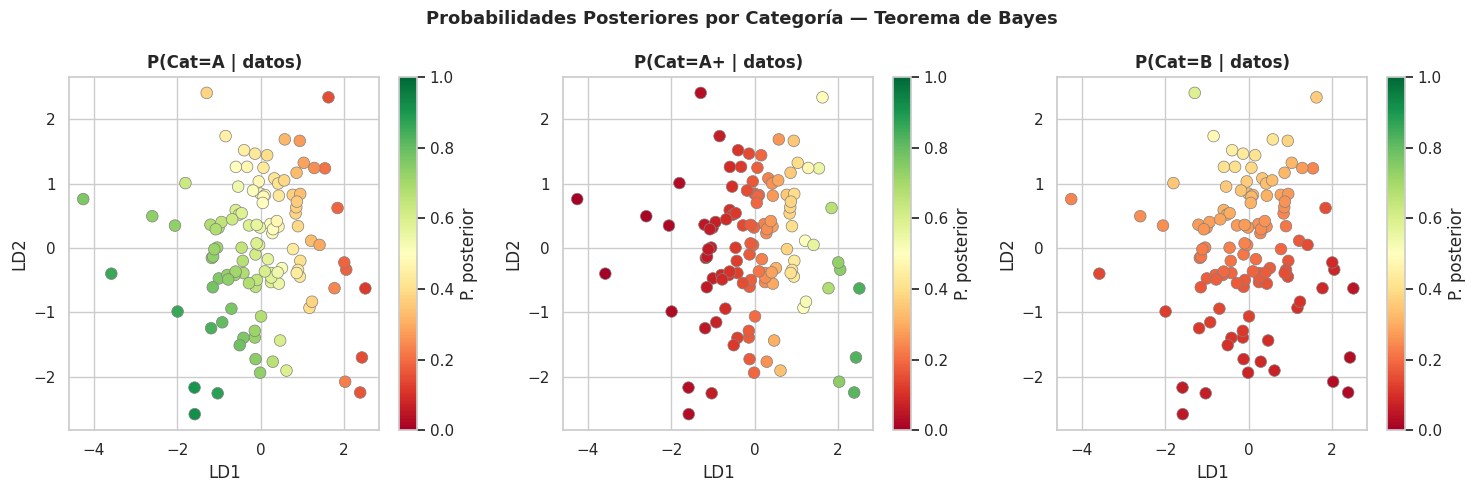

In [25]:
# ── Mapa de probabilidades posteriores ──
fig, axes = plt.subplots(1, len(clases), figsize=(5*len(clases), 5))

for i, (cls, ax) in enumerate(zip(clases, axes)):
    prob_cls = proba_posterior[:, i]
    scatter = ax.scatter(LD_scores[:, 0],
                          LD_scores[:, 1] if n_func >= 2 else np.zeros(len(LD_scores)),
                          c=prob_cls, cmap='RdYlGn', vmin=0, vmax=1,
                          s=70, edgecolors='gray', lw=0.5)
    plt.colorbar(scatter, ax=ax, label='P. posterior')
    ax.set_title(f'P(Cat={cls} | datos)', fontsize=12, fontweight='bold')
    ax.set_xlabel('LD1')
    if n_func >= 2:
        ax.set_ylabel('LD2')

plt.suptitle('Probabilidades Posteriores por Categoría — Teorema de Bayes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

🔍 CLIENTES MAL CLASIFICADOS POR LDA: 46 de 114 (40.4%)
    cliente Clase_Predicha_LDA  P_posterior_A  P_posterior_A+  P_posterior_B
5         A                 A+         0.2272          0.7420         0.0309
7        A+                  A         0.4349          0.3759         0.1892
8         B                  A         0.4908          0.1768         0.3325
11        B                  A         0.6683          0.0643         0.2674
13       A+                  A         0.4330          0.1783         0.3887
14        A                 A+         0.3306          0.5003         0.1690
16        B                  A         0.5527          0.1845         0.2629
19        B                  A         0.5401          0.1007         0.3593
20        A                  B         0.3187          0.2621         0.4192
21        B                  A         0.6480          0.1202         0.2317
22        A                 A+         0.4079          0.4302         0.1619
23        A          

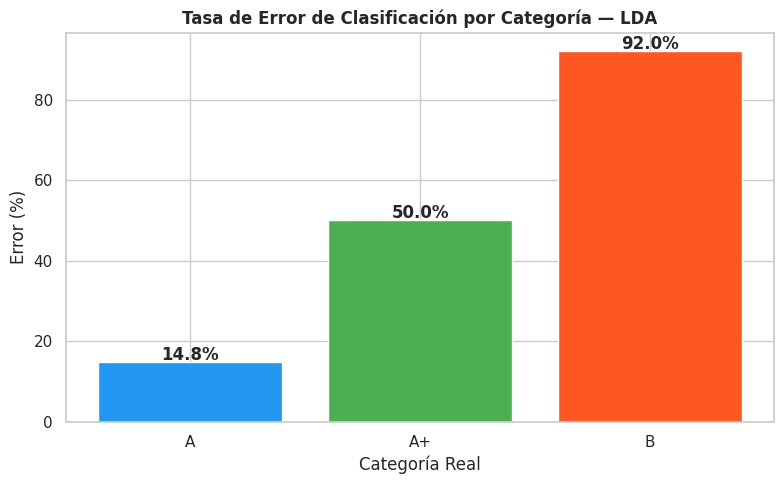

In [26]:
# ── Clientes mal clasificados ──
mal_clasificados = df_resultados[~df_resultados['Correcta']].copy()
print(f'🔍 CLIENTES MAL CLASIFICADOS POR LDA: {len(mal_clasificados)} de {len(df)} ({len(mal_clasificados)/len(df)*100:.1f}%)')

if len(mal_clasificados) > 0:
    cols_mc = ['cliente', 'Clase_Predicha_LDA'] + [f'P_posterior_{c}' for c in clases]
    print(mal_clasificados[cols_mc].to_string())

    # Gráfico
    fig, ax = plt.subplots(figsize=(8, 5))
    error_por_clase = mal_clasificados.groupby('Clase_Real').size()
    total_por_clase = df_resultados.groupby('Clase_Real').size()
    tasa_error = (error_por_clase / total_por_clase * 100).fillna(0)
    bars = ax.bar(tasa_error.index, tasa_error.values,
                  color=[COLORS.get(c, '#999') for c in tasa_error.index], edgecolor='white')
    for bar, val in zip(bars, tasa_error.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold')
    ax.set_title('Tasa de Error de Clasificación por Categoría — LDA', fontweight='bold')
    ax.set_xlabel('Categoría Real')
    ax.set_ylabel('Error (%)')
    plt.tight_layout()
    plt.show()

## 10. Ajuste del Modelo QDA (Análisis Discriminante Cuadrático)

In [27]:
# ── QDA: se usa cuando las matrices de covarianza NO son iguales entre grupos ──
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_scaled, y_enc)

y_pred_qda_enc = qda.predict(X_scaled)
y_pred_qda = le.inverse_transform(y_pred_qda_enc)
proba_qda = qda.predict_proba(X_scaled)

acc_qda = accuracy_score(y, y_pred_qda)
err_qda = (1 - acc_qda) * 100

print('=' * 60)
print('MODELO QDA — RESULTADOS')
print('=' * 60)
print(f'\nAccuracy QDA:      {acc_qda:.4f} ({acc_qda*100:.2f}%)')
print(f'Training error QDA: {err_qda:.2f}%')

print('\n📊 Tabla de clasificación QDA:')
tabla_qda = pd.crosstab(pd.Series(y, name='Clase Real'),
                         pd.Series(y_pred_qda, name='Clase Predicha QDA'),
                         margins=True, margins_name='Total')
print(tabla_qda)

# Validación cruzada QDA
cv_qda = cross_val_score(QuadraticDiscriminantAnalysis(),
                          X_scaled, y_enc, cv=StratifiedKFold(5, shuffle=True, random_state=42))
print(f'\n5-Fold CV QDA: {cv_qda.mean():.4f} ± {cv_qda.std():.4f}')

loo_qda = cross_val_score(QuadraticDiscriminantAnalysis(),
                           X_scaled, y_enc, cv=LeaveOneOut())
print(f'LOO CV QDA:    {loo_qda.mean():.4f} ({loo_qda.mean()*100:.2f}%)')

MODELO QDA — RESULTADOS

Accuracy QDA:      0.4474 (44.74%)
Training error QDA: 55.26%

📊 Tabla de clasificación QDA:
Clase Predicha QDA  A  A+   B  Total
Clase Real                          
A                   8  20  33     61
A+                  0  20   8     28
B                   0   2  23     25
Total               8  42  64    114

5-Fold CV QDA: 0.3249 ± 0.1286
LOO CV QDA:    0.2456 (24.56%)


## 11. Comparación LDA vs QDA

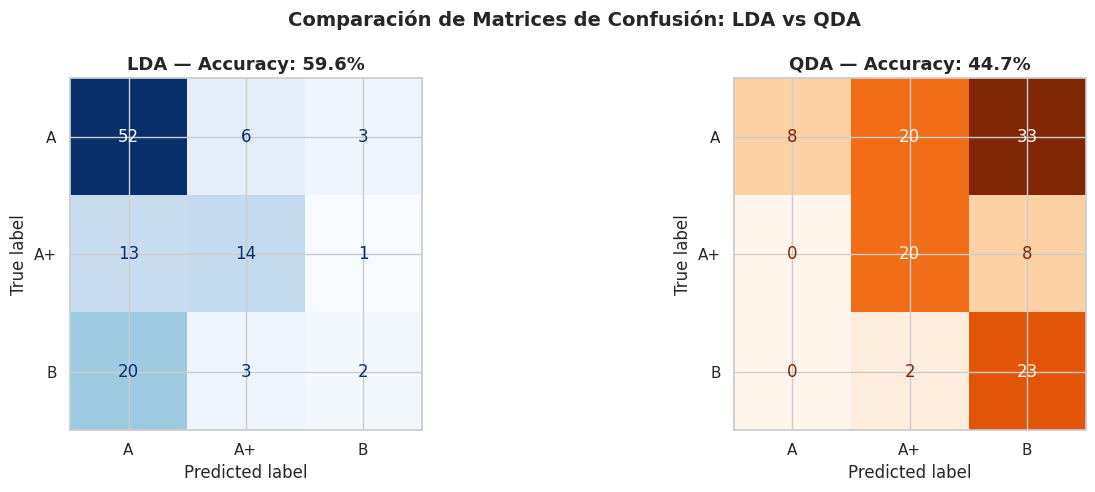

In [28]:
# ── Comparación visual de matrices de confusión ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lda = confusion_matrix(y, y_pred, labels=clases)
cm_qda = confusion_matrix(y, y_pred_qda, labels=clases)

ConfusionMatrixDisplay(cm_lda, display_labels=clases).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'LDA — Accuracy: {accuracy*100:.1f}%', fontweight='bold', fontsize=13)

ConfusionMatrixDisplay(cm_qda, display_labels=clases).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'QDA — Accuracy: {acc_qda*100:.1f}%', fontweight='bold', fontsize=13)

plt.suptitle('Comparación de Matrices de Confusión: LDA vs QDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# ── Tabla comparativa de métricas ──
print('=' * 65)
print('COMPARACIÓN FINAL: LDA vs QDA')
print('=' * 65)

cv_lda_5 = cross_val_score(LinearDiscriminantAnalysis(solver='svd'),
                            X_scaled, y_enc,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42))

tabla_comp = pd.DataFrame({
    'Métrica': [
        'Training Accuracy',
        'Training Error (%)',
        '5-Fold CV Accuracy',
        '5-Fold CV Std',
        'LOO CV Accuracy',
        'LOO Error (%)'
    ],
    'LDA': [
        f'{accuracy:.4f}',
        f'{training_error:.2f}%',
        f'{cv_scores.mean():.4f}',
        f'±{cv_scores.std():.4f}',
        f'{loo_scores.mean():.4f}',
        f'{(1-loo_scores.mean())*100:.2f}%'
    ],
    'QDA': [
        f'{acc_qda:.4f}',
        f'{err_qda:.2f}%',
        f'{cv_qda.mean():.4f}',
        f'±{cv_qda.std():.4f}',
        f'{loo_qda.mean():.4f}',
        f'{(1-loo_qda.mean())*100:.2f}%'
    ]
})
print(tabla_comp.to_string(index=False))

print('\n📌 Interpretación:')
print('   • LDA asume matriz de covarianza igual en todos los grupos.')
print('   • QDA asume matrices de covarianza distintas por grupo.')
mejor = 'LDA' if loo_scores.mean() >= loo_qda.mean() else 'QDA'
print(f'   • Según LOO CV, el modelo {mejor} tiene mejor rendimiento generalizable.')

COMPARACIÓN FINAL: LDA vs QDA
           Métrica     LDA     QDA
 Training Accuracy  0.5965  0.4474
Training Error (%)  40.35%  55.26%
5-Fold CV Accuracy  0.5348  0.3249
     5-Fold CV Std ±0.0379 ±0.1286
   LOO CV Accuracy  0.4649  0.2456
     LOO Error (%)  53.51%  75.44%

📌 Interpretación:
   • LDA asume matriz de covarianza igual en todos los grupos.
   • QDA asume matrices de covarianza distintas por grupo.
   • Según LOO CV, el modelo LDA tiene mejor rendimiento generalizable.


## 12. Predicción de Nuevos Clientes

In [30]:
# ── Función para clasificar nuevos clientes ──
def clasificar_nuevo_cliente(valores_dict, modelo='LDA'):
    """
    Clasifica un nuevo cliente usando LDA o QDA.

    Parámetros:
    -----------
    valores_dict : dict con los valores de las variables independientes
    modelo       : 'LDA' o 'QDA'

    Retorna:
    --------
    Categoría predicha y probabilidades posteriores
    """
    # Completar con medianas si faltan variables
    medianas = df[VARS_INDEP].median()
    fila = [valores_dict.get(v, medianas[v]) for v in VARS_INDEP]
    X_nuevo = np.array(fila).reshape(1, -1)
    X_nuevo_sc = scaler.transform(X_nuevo)

    clf = lda if modelo == 'LDA' else qda
    pred_enc = clf.predict(X_nuevo_sc)
    pred_cat = le.inverse_transform(pred_enc)[0]
    proba = clf.predict_proba(X_nuevo_sc)[0]

    print(f'\n{'='*55}')
    print(f'CLASIFICACIÓN DE NUEVO CLIENTE — {modelo}')
    print(f'{'='*55}')
    print(f'\n🏷️  Categoría predicha: [{pred_cat}]')
    print('\n📊 Probabilidades posteriores:')
    for cls, p in sorted(zip(clases, proba), key=lambda x: -x[1]):
        barra = '█' * int(p * 30)
        print(f'   P(Cat={cls} | datos) = {p:.4f}  {barra}')

    return pred_cat, dict(zip(clases, proba))


# Ejemplo 1: Cliente con buen perfil
cliente_nuevo_1 = {
    'mora promedio del cliente (dias)': 0.5,
    'atraso maximo del cliente (dias)': 3,
    'atraso maximo del cliente ultimos 3 meses (dias)': 1,
    'numero de creditos vigentes': 1,
    'maximo capital desembolsado vigente': 5000,
    'deuda total en compartamos': 4000,
    'numero de empresas en la SBS': 1,
    'deuda directa en la SBS': 4500,
    'Ingresos': 8000,
    'egresos': 4500,
    'resultado neto': 3500,
    'monto aprobado de cash': 5000
}

print('EJEMPLO 1: Cliente con buen perfil crediticio')
clasificar_nuevo_cliente(cliente_nuevo_1, modelo='LDA')
clasificar_nuevo_cliente(cliente_nuevo_1, modelo='QDA')

# Ejemplo 2: Cliente con perfil de mayor riesgo
cliente_nuevo_2 = {
    'mora promedio del cliente (dias)': 3.5,
    'atraso maximo del cliente (dias)': 20,
    'atraso maximo del cliente ultimos 3 meses (dias)': 10,
    'numero de creditos vigentes': 2,
    'maximo capital desembolsado vigente': 2000,
    'deuda total en compartamos': 1500,
    'numero de empresas en la SBS': 3,
    'deuda directa en la SBS': 8000,
    'Ingresos': 3000,
    'egresos': 2500,
    'resultado neto': 500,
    'monto aprobado de cash': 1000
}

print('\nEJEMPLO 2: Cliente con perfil de mayor riesgo')
clasificar_nuevo_cliente(cliente_nuevo_2, modelo='LDA')
clasificar_nuevo_cliente(cliente_nuevo_2, modelo='QDA')

EJEMPLO 1: Cliente con buen perfil crediticio

CLASIFICACIÓN DE NUEVO CLIENTE — LDA

🏷️  Categoría predicha: [A]

📊 Probabilidades posteriores:
   P(Cat=A | datos) = 0.4834  ██████████████
   P(Cat=A+ | datos) = 0.3024  █████████
   P(Cat=B | datos) = 0.2142  ██████

CLASIFICACIÓN DE NUEVO CLIENTE — QDA

🏷️  Categoría predicha: [A+]

📊 Probabilidades posteriores:
   P(Cat=A+ | datos) = 0.9702  █████████████████████████████
   P(Cat=B | datos) = 0.0298  
   P(Cat=A | datos) = 0.0000  

EJEMPLO 2: Cliente con perfil de mayor riesgo

CLASIFICACIÓN DE NUEVO CLIENTE — LDA

🏷️  Categoría predicha: [A]

📊 Probabilidades posteriores:
   P(Cat=A | datos) = 0.7811  ███████████████████████
   P(Cat=B | datos) = 0.1974  █████
   P(Cat=A+ | datos) = 0.0216  

CLASIFICACIÓN DE NUEVO CLIENTE — QDA

🏷️  Categoría predicha: [A+]

📊 Probabilidades posteriores:
   P(Cat=A+ | datos) = 0.8882  ██████████████████████████
   P(Cat=B | datos) = 0.1118  ███
   P(Cat=A | datos) = 0.0000  


('A+',
 {'A': np.float64(1.2958555892033355e-10),
  'A+': np.float64(0.8881510816388684),
  'B': np.float64(0.11184891823154615)})

## 13. Exportación de Resultados

In [31]:
# ── Guardar tabla completa de reclasificación ──
# Agregar predicciones QDA también
df_resultados['Clase_Predicha_QDA'] = y_pred_qda
df_resultados['Correcta_QDA'] = df_resultados['Clase_Real'] == df_resultados['Clase_Predicha_QDA']
for i, cls in enumerate(clases):
    df_resultados[f'P_posterior_QDA_{cls}'] = proba_qda[:, i].round(4)

nombre_archivo = 'reclasificacion_clientes_LDA_QDA.xlsx'
df_resultados.to_excel(nombre_archivo, index=False)

# Descargar desde Colab
from google.colab import files
files.download(nombre_archivo)
print(f'✅ Archivo guardado y descargado: {nombre_archivo}')
print(f'   Filas: {len(df_resultados)} | Columnas: {len(df_resultados.columns)}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivo guardado y descargado: reclasificacion_clientes_LDA_QDA.xlsx
   Filas: 114 | Columnas: 26


## 14. Resumen Ejecutivo y Conclusiones

In [32]:
print('=' * 70)
print('RESUMEN EJECUTIVO — ANÁLISIS DISCRIMINANTE DE BUENOS CLIENTES')
print('=' * 70)
print(f"""
1. DATOS
   • Total de clientes analizados: {len(df)}
   • Variables independientes usadas: {len(VARS_INDEP)}
   • Variable dependiente: Categoría del cliente (A, A+, B)
   • Distribución: A={sum(y=='A')} ({sum(y=='A')/len(y)*100:.1f}%) |
                   A+={sum(y=='A+')} ({sum(y=='A+')/len(y)*100:.1f}%) |
                   B={sum(y=='B')} ({sum(y=='B')/len(y)*100:.1f}%)

2. SUPUESTOS
   • Normalidad: No todas las variables cumplen normalidad univariante
     (LDA es robusto ante esta violación moderada)
   • Homogeneidad de covarianzas: Evaluada con test de Levene
   • Multicolinealidad: Revisada mediante correlaciones

3. RESULTADOS LDA
   • Funciones discriminantes: {n_func} (LD1 explica {exp_var[0]*100:.1f}% de la varianza)
   • Training Accuracy: {accuracy*100:.2f}%
   • Training Error: {training_error:.2f}%
   • 5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%
   • LOO CV Accuracy: {loo_scores.mean()*100:.2f}%

4. RESULTADOS QDA
   • Training Accuracy: {acc_qda*100:.2f}%
   • Training Error: {err_qda:.2f}%
   • 5-Fold CV Accuracy: {cv_qda.mean()*100:.2f}% ± {cv_qda.std()*100:.2f}%
   • LOO CV Accuracy: {loo_qda.mean()*100:.2f}%

5. RECOMENDACIÓN
   • Modelo recomendado: {'LDA' if loo_scores.mean() >= loo_qda.mean() else 'QDA'}
     (mayor accuracy en LOO CV = mejor generalización)
   • Las variables más discriminantes según LD1 son aquellas con mayor
     coeficiente absoluto en la función discriminante.

6. CONCLUSIÓN
   El análisis discriminante permite reclasificar correctamente a la
   gran mayoría de los buenos clientes según sus características
   financieras y crediticias. El modelo puede usarse para:
   (a) validar clasificaciones existentes,
   (b) identificar clientes mal clasificados, y
   (c) clasificar nuevos clientes automáticamente.
""")
print('=' * 70)

RESUMEN EJECUTIVO — ANÁLISIS DISCRIMINANTE DE BUENOS CLIENTES

1. DATOS
   • Total de clientes analizados: 114
   • Variables independientes usadas: 12
   • Variable dependiente: Categoría del cliente (A, A+, B)
   • Distribución: A=61 (53.5%) |
                   A+=28 (24.6%) |
                   B=25 (21.9%)

2. SUPUESTOS
   • Normalidad: No todas las variables cumplen normalidad univariante
     (LDA es robusto ante esta violación moderada)
   • Homogeneidad de covarianzas: Evaluada con test de Levene
   • Multicolinealidad: Revisada mediante correlaciones

3. RESULTADOS LDA
   • Funciones discriminantes: 2 (LD1 explica 79.3% de la varianza)
   • Training Accuracy: 59.65%
   • Training Error: 40.35%
   • 5-Fold CV Accuracy: 53.48% ± 3.79%
   • LOO CV Accuracy: 46.49%

4. RESULTADOS QDA
   • Training Accuracy: 44.74%
   • Training Error: 55.26%
   • 5-Fold CV Accuracy: 32.49% ± 12.86%
   • LOO CV Accuracy: 24.56%

5. RECOMENDACIÓN
   • Modelo recomendado: LDA
     (mayor accuracy en